#### 1) Importing Necessary Libraries:

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

import warnings
warnings.filterwarnings('ignore')

#### 2) Loading Data:

In [2]:
df = pd.read_csv('moviereviews.csv')

In [3]:
df.head()

,label,review
0,neg,how do films like mouse hunt get into theatres...
1,neg,some talented actresses are blessed with a dem...
2,pos,this has been an extraordinary year for austra...
3,pos,according to hollywood movies made in last few...
4,neg,my first press screening of 1998 and already i...


In [4]:
df.shape

(2000, 2)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   label   2000 non-null   object
 1   review  1965 non-null   object
dtypes: object(2)
memory usage: 31.4+ KB


In [6]:
# Removing Records with Missing Target Values ('review'):

df = df.dropna()

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1965 entries, 0 to 1999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   label   1965 non-null   object
 1   review  1965 non-null   object
dtypes: object(2)
memory usage: 46.1+ KB


#### 3) Data Cleaning:

##### 1) Checking if any Reviews are Blank Strings like "" or " " or  "  ":
https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.Series.str.isspace.html

In [8]:
"".isspace()

False

In [9]:
" ".isspace()

True

In [10]:
"Batman ".isspace()

False

In [11]:
# Checkign for Records having Blank Reviews:

df['review'].str.isspace()

0       False
1       False
2       False
3       False
4       False
        ...  
1995    False
1996    False
1997    False
1998    False
1999    False
Name: review, Length: 1965, dtype: bool

In [12]:
df['review'].str.isspace().sum()

np.int64(27)

In [13]:
# Records with Blank reviews:

df[df['review'].str.isspace()]

,label,review
57,neg,
71,pos,
147,pos,
151,pos,
283,pos,
307,pos,
313,neg,
323,pos,
343,pos,
351,neg,


In [14]:
# Removing Records with Blank Reviews:

df = df[df['review'].str.isspace() != True]

In [15]:
df

,label,review
0,neg,how do films like mouse hunt get into theatres...
1,neg,some talented actresses are blessed with a dem...
2,pos,this has been an extraordinary year for austra...
3,pos,according to hollywood movies made in last few...
4,neg,my first press screening of 1998 and already i...
...,...,...
1995,pos,"i like movies with albert brooks , and i reall..."
1996,pos,it might surprise some to know that joel and e...
1997,pos,the verdict : spine-chilling drama from horror...
1998,pos,i want to correct what i wrote in a former ret...


In [16]:
df.shape

(1938, 2)

#### 4) Train Test Split:

In [17]:
X = df['review'] # Feature
y = df['label'] # Target

In [18]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2, random_state= 42)

In [19]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(1550,)
(388,)
(1550,)
(388,)


#### 5) Tf-Idf vectorizer:

In [21]:
tfidf = TfidfVectorizer(stop_words= 'english')
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [22]:
X_train_tfidf

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 378038 stored elements and shape (1550, 35472)>

In [23]:
X_test_tfidf

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 89585 stored elements and shape (388, 35472)>

#### 6) Model Building and Evaluation:

In [26]:
# Function to Fit and Evaluate Model:

def model_fit_predict(model, param_dict):
    """
    model: Model Estimator to be Evaluated.
    param_dict: Paramter Dictionary to use into Passed Estimator using Grid Search.
    """

    grid = GridSearchCV(estimator= model, param_grid= param_dict, cv= 5)
    grid.fit(X_train_tfidf, y_train)

    # Best Parameters according to Grid Search:
    print('Best Parameters:\n')
    print(grid.best_params_)
    print('\n')

    # Predictions Using Best Estimator from Grid Search:
    y_pred = grid.predict(X_test_tfidf)
    
    # Classification Report:
    print('Classification Report:\n')
    print(classification_report(y_test, y_pred))
    print('\n')
    
    # Confusion Matrix:
    print('Confusion Matrix:\n')
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels= grid.classes_)
    disp.plot()
    plt.show()

Best Parameters:

{'alpha': 1, 'fit_prior': False}


Classification Report:

              precision    recall  f1-score   support

         neg       0.78      0.87      0.83       188
         pos       0.87      0.78      0.82       200

    accuracy                           0.82       388
   macro avg       0.83      0.82      0.82       388
weighted avg       0.83      0.82      0.82       388



Confusion Matrix:



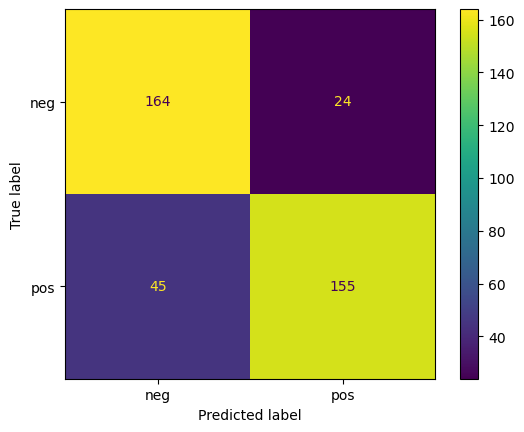

In [27]:
# Grid Search on Naive Bayes Classifier:

nb_model = MultinomialNB()
param_dict = {'alpha' : [0, 0.01, 0.1, 0.5, 1],
             'fit_prior' : [True, False]}

model_fit_predict(model= nb_model, param_dict= param_dict)

Best Parameters:

{'C': np.float64(12.91549665014884), 'l1_ratio': 0, 'penalty': 'l2'}


Classification Report:

              precision    recall  f1-score   support

         neg       0.85      0.85      0.85       188
         pos       0.86      0.86      0.86       200

    accuracy                           0.85       388
   macro avg       0.85      0.85      0.85       388
weighted avg       0.85      0.85      0.85       388



Confusion Matrix:



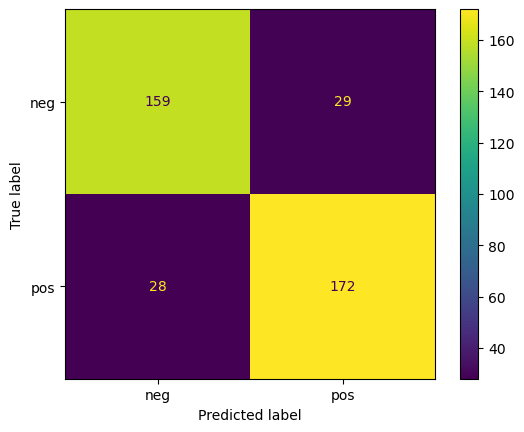

In [28]:
# Grid Search on Logisitc Regression Classifier:

lr_model = LogisticRegression()
param_dict = {'penalty' : ["l1", "l2", "elasticnet"],
              'C' : np.logspace(0, 5, 10),
              'l1_ratio' : [0, 0.01, 0.1, 0.25, 0.5, 0.75, 0.9, 0.99, 1]}

model_fit_predict(model= lr_model, param_dict= param_dict)